In [21]:
import openai
from dotenv import load_dotenv

load_dotenv()

%load_ext mypy_ipython

The mypy_ipython extension is already loaded. To reload it, use:
  %reload_ext mypy_ipython


### Import relevant classes


In [22]:
from langgraph.graph import START, END, StateGraph
from typing_extensions import TypedDict
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_core.runnables import Runnable
from collections.abc import Sequence

### Define the State


In [23]:
class State(TypedDict):
    messages: Sequence[BaseMessage]

In [24]:
state = State(messages=[HumanMessage(content="Create a poem about nature")])

In [25]:
state

{'messages': [HumanMessage(content='Create a poem about nature', additional_kwargs={}, response_metadata={})]}

In [26]:
state["messages"][0].pretty_print()

================================ Human Message =================================

Create a poem about nature


### Define the Nodes


In [27]:
chat = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0,
    seed=42,
    max_completion_tokens=100,
)

In [28]:
response = chat.invoke(state["messages"])

In [29]:
response.pretty_print()

================================== Ai Message ==================================

Beneath the sky so vast and blue,  
The whispering winds sing soft and true,  
Through forests deep where shadows play,  
And golden beams of light hold sway.  

The rivers dance on stones so bright,  
Reflecting stars that pierce the night,  
Mountains stand with ancient grace,  
Guardians of this sacred place.  

Flowers bloom in colors bold,  
Stories of the earth retold,  
In every leaf and every tree,  
A song of life


In [30]:
def chatbot(state: State) -> State:
    print(f"\n----> Entering chatbot:")

    response = chat.invoke(state["messages"])
    response.pretty_print()

    return State(messages=[response])

In [31]:
chatbot(state)


----> Entering chatbot:
================================== Ai Message ==================================

Beneath the sky so vast and blue,  
Where morning drips with sparkling dew,  
The whispering leaves in gentle dance,  
Invite the soul to dream and chance.  

Mountains rise with ancient grace,  
Their peaks a cold, embracing face,  
Rivers sing their endless song,  
Carving paths both deep and long.  

Flowers bloom in colors bright,  
Painting meadows with pure light,  
The breeze carries a sweet perfume,  
A tender kiss from earth


{'messages': [AIMessage(content='Beneath the sky so vast and blue,  \nWhere morning drips with sparkling dew,  \nThe whispering leaves in gentle dance,  \nInvite the soul to dream and chance.  \n\nMountains rise with ancient grace,  \nTheir peaks a cold, embracing face,  \nRivers sing their endless song,  \nCarving paths both deep and long.  \n\nFlowers bloom in colors bright,  \nPainting meadows with pure light,  \nThe breeze carries a sweet perfume,  \nA tender kiss from earth', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 12, 'total_tokens': 112, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_376a7ccef1', 'id': 'chatcmpl-CrsfNtoSRQ1oD7xWnX7leNGnO9jJw', 'service_tier': 'default', 'finish_reaso

In [32]:
graph = StateGraph(State)

In [33]:
graph.add_node("chatbot", chatbot)

graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

In [34]:
graph_compiled = graph.compile()

In [35]:
isinstance(graph_compiled, Runnable)

True

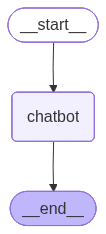

In [36]:
graph_compiled

### Test the Graph


In [37]:
graph_compiled.invoke(state)


----> Entering chatbot:
================================== Ai Message ==================================

Beneath the sky so vast and blue,  
Where morning drips with sparkling dew,  
The whispering leaves in gentle dance,  
Invite the soul to dream and chance.  

Mountains rise with ancient grace,  
Their peaks a cold, embracing face,  
Rivers sing their endless song,  
Carving paths both deep and long.  

Flowers bloom in colors bright,  
Painting meadows with pure light,  
The breeze carries a sweet perfume,  
A tender kiss from earth


{'messages': [AIMessage(content='Beneath the sky so vast and blue,  \nWhere morning drips with sparkling dew,  \nThe whispering leaves in gentle dance,  \nInvite the soul to dream and chance.  \n\nMountains rise with ancient grace,  \nTheir peaks a cold, embracing face,  \nRivers sing their endless song,  \nCarving paths both deep and long.  \n\nFlowers bloom in colors bright,  \nPainting meadows with pure light,  \nThe breeze carries a sweet perfume,  \nA tender kiss from earth', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 12, 'total_tokens': 112, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_376a7ccef1', 'id': 'chatcmpl-CrsfYNg2RKqcRDksQslJcP1bSnmAe', 'service_tier': 'default', 'finish_reaso